---
# Initial Setup
1. Clone the repo
2. change directory
3. switch branches

In [1]:
!git clone https://github.com/Dewnan/NLP_Group_15.git
%cd NLP_Group_15
!git checkout feature/CIT-24-01-0020-model

Cloning into 'NLP_Group_15'...
remote: Enumerating objects: 313, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 313 (delta 57), reused 80 (delta 24), pack-reused 176 (from 1)
Receiving objects: 100% (313/313), 42.33 MiB | 15.81 MiB/s, done.
Resolving deltas: 100% (131/131), done.
/content/NLP_Group_15
Branch 'feature/CIT-24-01-0020-model' set up to track remote branch 'feature/CIT-24-01-0020-model' from 'origin'.
Switched to a new branch 'feature/CIT-24-01-0020-model'


---
**! Before Running the rest import the username and key from the Kaggle in to the colab secrets**
---

In [2]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from src.data_downloader import download_dataset
from src.preprocess import load_and_merge, build_content_and_clean, apply_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [3]:
dataset_path = download_dataset()
print(f'Dataset downloaded to: {dataset_path}')

100%|██████████| 41.0M/41.0M [00:00<00:00, 184MB/s]

Extracting files...


Dataset downloaded to: data


---
**Process the data set**

In [13]:
try:
    if os.path.exists('data/processed'):
        shutil.rmtree('data/processed')
    os.mkdir('data/processed')
except Exception as e:
    print(f'Failed to remove existing data sets / create a folder: {e}')

try:
    merged_df = load_and_merge()
    merged_df.to_csv('data/processed/merged_news.csv', index=False)
except Exception as e:
    print(f'Failed to merge data sets: {e}')

try:
    cleaned_df = build_content_and_clean(merged_df)
    cleaned_df.to_csv('data/processed/cleaned_news.csv', index=False)
except Exception as e:
    print(f'Failed to clean data sets: {e}')

try:
    tokenize_and_lemmatize_df = apply_tokenize(cleaned_df)
    tokenize_and_lemmatize_df.to_csv('data/processed/tokenized_news.csv', index=False)
except Exception as e:
    print(f'Failed to tokenize data sets: {e}')

Dropped 6071 duplicate rows
Dropped 3 rows with empty or near empty content


# Exploratory Data Analysis

## Class distribution

Class Destribution after merging datasets

Class Counts: 
label
0    21417
1    23481
Name: count, dtype: int64

Real data count: 21417, Percentage: 47.7%
Fake data count: 23481, Percentage: 52.3%


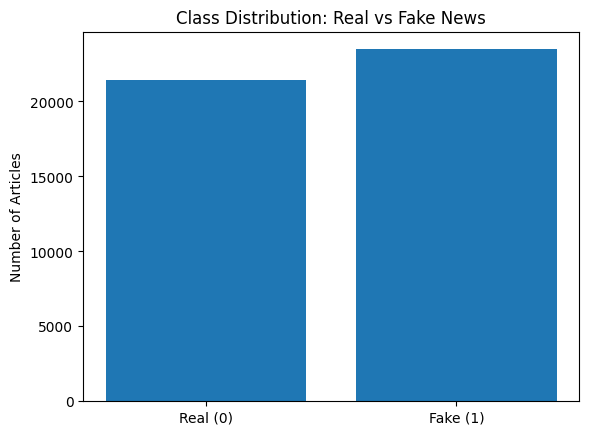

In [5]:
merged_df = pd.read_csv('data/processed/merged_news.csv')

class_counts = merged_df['label'].value_counts().sort_index()
print(f'Class Counts: \n{class_counts}\n')

real_count = class_counts[0]
fake_count = class_counts[1]
total = len(merged_df)

real_percent = real_count / total * 100
fake_percent = fake_count / total * 100

print(f"Real data count: {real_count}, Percentage: {real_percent:.1f}%")
print(f"Fake data count: {fake_count}, Percentage: {fake_percent:.1f}%")

plt.bar(['Real (0)', 'Fake (1)'], class_counts.values, width=0.8)
plt.title('Class Distribution: Real vs Fake News')
plt.ylabel('Number of Classes')
plt.ylabel('Number of Articles')
plt.show()

## Text Length Distribution

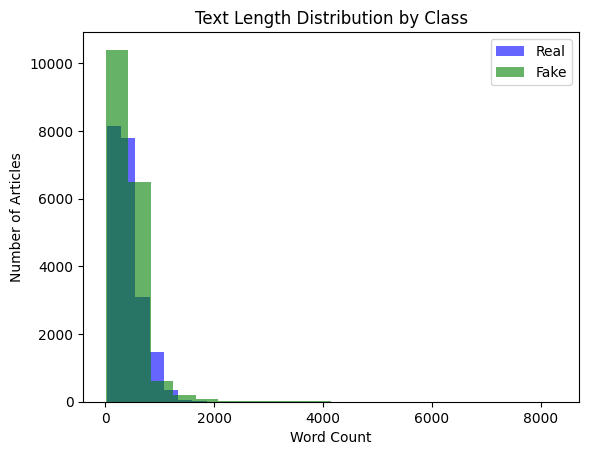

         count        mean         std   min    25%    50%    75%     max
label                                                                    
0      20925.0  397.788244  276.336073  29.0  159.0  371.0  536.0  5254.0
1      17899.0  431.103134  360.947465   6.0  281.0  387.0  516.0  8289.0


In [12]:
cleaned_df = pd.read_csv('data/processed/cleaned_news.csv')

def word_counter(text):
  words = str(text).split()
  return len(words)

cleaned_df['word_count'] = cleaned_df['content'].apply(word_counter)

real_article_Wcount = cleaned_df[cleaned_df['label'] == 0]['word_count']
fake_article_Wcount = cleaned_df[cleaned_df['label'] == 1]['word_count']

plt.hist(real_article_Wcount, bins=20, alpha=0.6, label='Real', color='blue')
plt.hist(fake_article_Wcount, bins=20, alpha=0.6, label='Fake', color='green')

plt.xlabel('Word Count')
plt.ylabel('Number of Articles')
plt.title('Text Length Distribution by Class')
plt.legend()
plt.show()

print(cleaned_df.groupby('label')['word_count'].describe())

Class distribution before and after data cleaning

In [10]:
print("Class distribution raw merged data:")
print(merged_df['label'].value_counts(normalize=True)*100)

print("\nClass distribution after cleaning:")
print(cleaned_df['label'].value_counts(normalize=True)*100)

Class distribution raw merged data:
label
1    52.298543
0    47.701457
Name: proportion, dtype: float64

Class distribution after cleaning:
label
0    53.897074
1    46.102926
Name: proportion, dtype: float64


## Word frequency analysis

In [18]:
from collections import Counter
tokenized_df = pd.read_csv('data/processed/tokenized_news.csv')

def get_top_words(text, word_count=20):
    all_words = ' '.join(text).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(word_count)

top_overall = get_top_words(tokenized_df['content'], word_count=20)
print("Top 20 words overall:")
for word, count in top_overall:
    print(f"{word}: {count}")

top_words_real = get_top_words(tokenized_df[tokenized_df['label'] == 0]['content'], word_count=20)
top_words_fake = get_top_words(tokenized_df[tokenized_df['label'] == 1]['content'], word_count=20)

print("\nTop 20 words in Real news:")
for word, count in top_words_real:
    print(f"{word}: {count}")

print("\nTop 20 words in Fake news:")
for word, count in top_words_fake:
    print(f"{word}: {count}")

Top 20 words overall:
trump: 134668
said: 121427
u: 66875
state: 54820
president: 50573
would: 49544
republican: 39224
people: 36798
year: 36722
one: 33665
reuters: 28739
new: 28449
house: 27083
also: 26956
government: 26617
donald: 26363
say: 25585
obama: 25091
clinton: 24912
time: 24493

Top 20 words in Real news:
said: 96473
trump: 58351
u: 49932
state: 37334
would: 31088
reuters: 28435
president: 28409
republican: 23747
year: 22403
government: 19889
house: 18120
new: 17402
also: 15527
party: 15433
people: 15129
election: 15104
united: 14936
official: 14622
told: 13882
country: 13797

Top 20 words in Fake news:
trump: 76317
said: 24954
president: 22164
people: 21669
one: 20078
would: 18456
state: 17486
u: 16943
donald: 16142
republican: 15477
like: 15166
obama: 15145
time: 14839
clinton: 14778
year: 14319
american: 13802
say: 12821
right: 12217
even: 11530
hillary: 11524


# !TODO: Remove 'u'.